# Part 2-3. Drift Prototype

첫 5개 정상(g) 평균을 reference로 두고, EMA 방식으로 공정 drift를 보정함

## 1. 데이터 읽기 및 설정

In [1]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# 학습 파라미터
SEED = 42
LEARNING_RATE = 0.001
EPOCHS = 200
TRAIN_G_COUNT = 5

# DaDrift 관련 파라미터
RE_THRESHOLD = 50
alpha = 0.7

random.seed(SEED)
np.random.seed(SEED)

# 데이터 경로 설정함
DATA_DIR = Path("data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 사용할 CSV 파일 설정함
csv_files = {
    "20230420": "20230420.csv",
    "20230426": "20230426.csv",
}

# CSV를 읽어서 저장함
datasets = {}

for name, file_name in csv_files.items():
    csv_path = DATA_DIR / file_name
    datasets[name] = pd.read_csv(csv_path)
    print(f"{name}: {datasets[name].shape}")

20230420: (1519, 201)
20230426: (1486, 201)


## 2. 첫 5개 g 샘플 선택 및 Reference 데이터 생성

In [2]:
# 첫 5개 g 샘플을 학습 데이터와 reference로 사용함
train_data = {}
reference_data = {}

for name, df in datasets.items():
    g_df = df[df["Results"] == "g"]
    base_g = g_df.head(TRAIN_G_COUNT)

    train_data[name] = base_g[force_cols].copy()
    reference_data[name] = train_data[name].mean(axis=0).to_numpy(dtype="float32")

    print(f"[{name}] 학습 데이터: {train_data[name].shape}")

[20230420] 학습 데이터: (5, 200)
[20230426] 학습 데이터: (5, 200)


## 3. AE 모델 학습

In [3]:
# 200 -> 32 -> 16 -> 32 -> 200 AE 모델 생성함
def build_autoencoder():
    return MLPRegressor(
        hidden_layer_sizes=(32, 16, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=LEARNING_RATE,
        max_iter=EPOCHS,
        random_state=SEED,
        early_stopping=False,
    )

In [4]:
# 파일별로 첫 5개 g 데이터로 AE 학습함
models_by_file = {}
scalers = {}

for name, x_train_df in train_data.items():
    x_train = x_train_df.apply(pd.to_numeric, errors="coerce")

    # 학습 정상 데이터 기준으로 표준화함
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)

    model = build_autoencoder()
    model.fit(x_train_scaled, x_train_scaled)

    models_by_file[name] = model
    scalers[name] = scaler

    print(f"[{name}] AE 학습 완료")
    print(f"학습률: {LEARNING_RATE}")
    print(f"Epoch: {EPOCHS}")
    print(f"반복 횟수: {model.n_iter_}")
    print(f"마지막 loss: {model.loss_:.6f}")

[20230420] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 170
마지막 loss: 0.002652
[20230426] AE 학습 완료
학습률: 0.001
Epoch: 200
반복 횟수: 161
마지막 loss: 0.002205


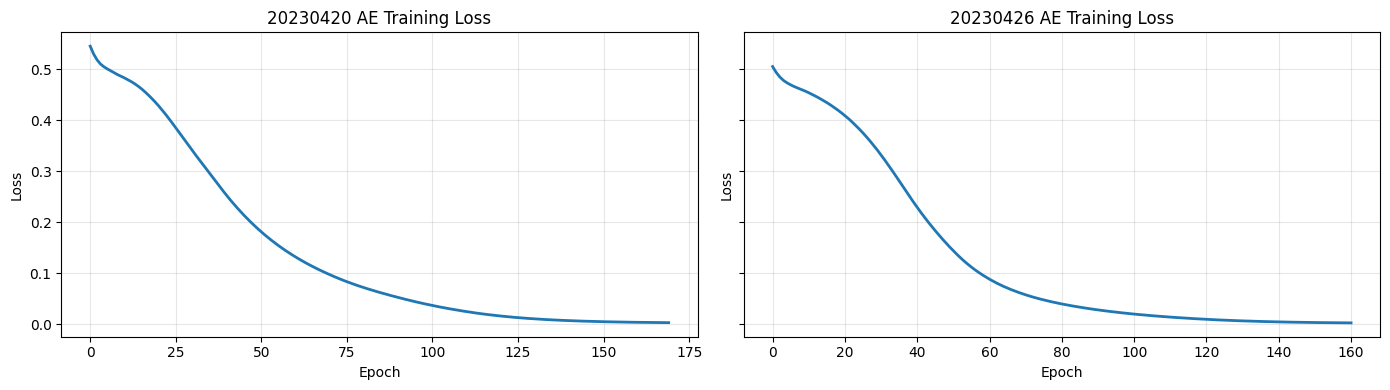

In [5]:
# 학습 loss 확인함
fig, axes = plt.subplots(1, len(models_by_file), figsize=(7 * len(models_by_file), 4), sharey=True)

if len(models_by_file) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models_by_file.items()):
    ax.plot(model.loss_curve_, color="#1f77b4", linewidth=2)
    ax.set_title(f"{name} AE Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Drift Reconstruction Error 계산

In [6]:
# 전체 포인트 평균 RE를 최종 RE로 사용함
drift_result_tables = {}

for name, df in datasets.items():
    x_all = df[force_cols].apply(pd.to_numeric, errors="coerce")

    model = models_by_file[name]
    scaler = scalers[name]
    reference = reference_data[name]

    # 처음 drift는 0으로 시작함
    drift = np.zeros(len(force_cols), dtype="float32")
    result_rows = []

    # 학습에 사용한 첫 5개 g 이후부터 테스트함
    for sample_idx in range(TRAIN_G_COUNT, len(x_all)):
        measured = x_all.iloc[sample_idx].to_numpy(dtype="float32")

        # 기존 방식 RE 계산함
        original_scaled = scaler.transform(
            pd.DataFrame([measured], columns=force_cols)
        )
        original_pred_scaled = model.predict(original_scaled)
        original_point_re = (original_scaled - original_pred_scaled) ** 2
        original_re = original_point_re.mean(axis=1)[0]

        # drift를 더해서 보정함
        corrected_measured = measured + drift

        # drift 보정 후 RE 계산함
        corrected_scaled = scaler.transform(
            pd.DataFrame([corrected_measured], columns=force_cols)
        )
        corrected_pred_scaled = model.predict(corrected_scaled)
        corrected_point_re = (corrected_scaled - corrected_pred_scaled) ** 2
        drift_re = corrected_point_re.mean(axis=1)[0]

        # 정상으로 판단되면 drift를 업데이트함 (EMA)
        is_update = drift_re <= RE_THRESHOLD

        if is_update:
            new_drift = reference - measured
            drift = (alpha * drift) + ((1-alpha) * new_drift)

        result_rows.append({
            "sample_index": sample_idx,
            "original_re": original_re,
            "drift_re": drift_re,
            "is_update": is_update,
            "Results": df.iloc[sample_idx]["Results"],
        })

    drift_result_tables[name] = pd.DataFrame(result_rows)

    print(f"[{name}] Drift RE Calculation Complete")
    display(drift_result_tables[name].head())

[20230420] Drift RE Calculation Complete


,sample_index,original_re,drift_re,is_update,Results
0,5,1.778176,1.778176,True,g
1,6,1.470657,1.944625,True,g
2,7,3.105423,2.947938,True,g
3,8,2.433041,2.143061,True,g
4,9,2.805743,1.937149,True,g


[20230426] Drift RE Calculation Complete


,sample_index,original_re,drift_re,is_update,Results
0,5,2.348721,2.348721,True,g
1,6,0.360180,0.374497,True,g
2,7,0.902172,0.789421,True,g
3,8,1.719622,1.023115,True,g
4,9,3.513985,2.826313,True,g


## 5. Drift RE Plot

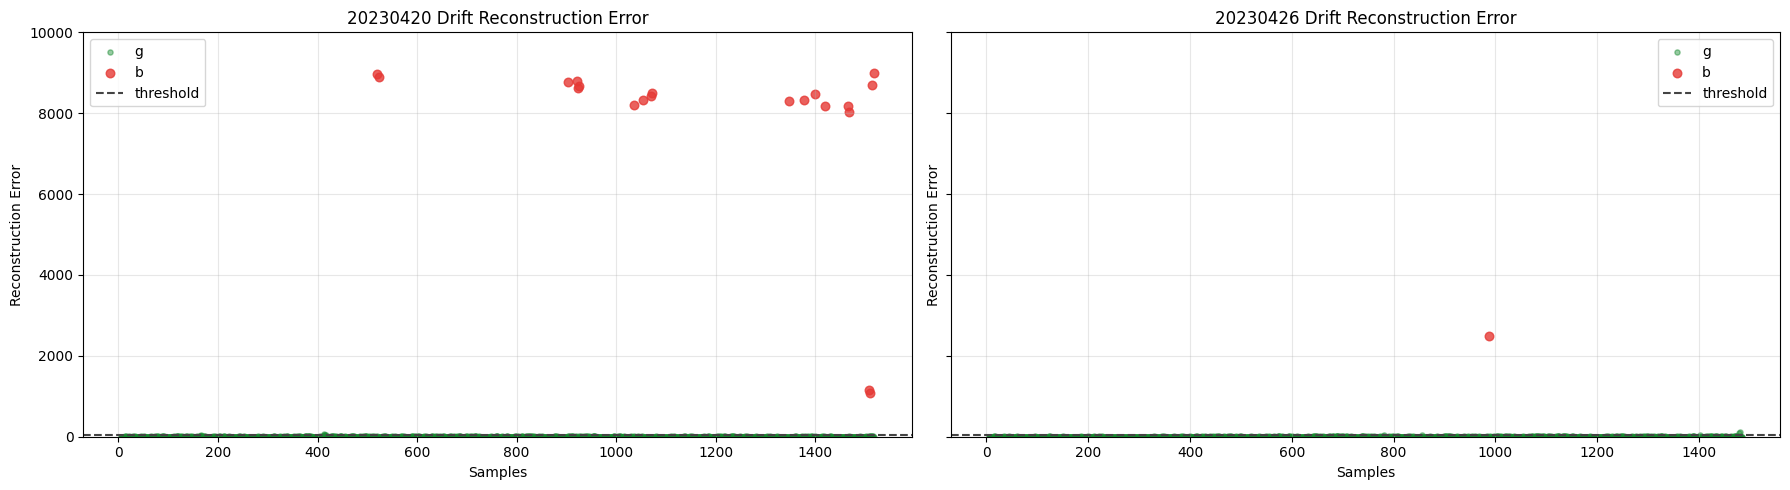

In [7]:
# drift 보정 RE를 표시함
fig, axes = plt.subplots(1, len(drift_result_tables), figsize=(9 * len(drift_result_tables), 5), sharey=True)

if len(drift_result_tables) == 1:
    axes = [axes]

for ax, (name, result_df) in zip(axes, drift_result_tables.items()):
    for label, color in [("g", "#168a2f"), ("b", "#e53935")]:
        label_df = result_df[result_df["Results"] == label]

        ax.scatter(
            label_df["sample_index"],
            label_df["drift_re"],
            color=color,
            alpha=0.8 if label == "b" else 0.45,
            s=38 if label == "b" else 14,
            label=label,
        )

    ax.axhline(RE_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5, label="threshold")
    ax.set_title(f"{name} Drift Reconstruction Error")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Reconstruction Error")
    ax.set_ylim(0, 10000)
    ax.set_yticks(range(0, 10001, 2000))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

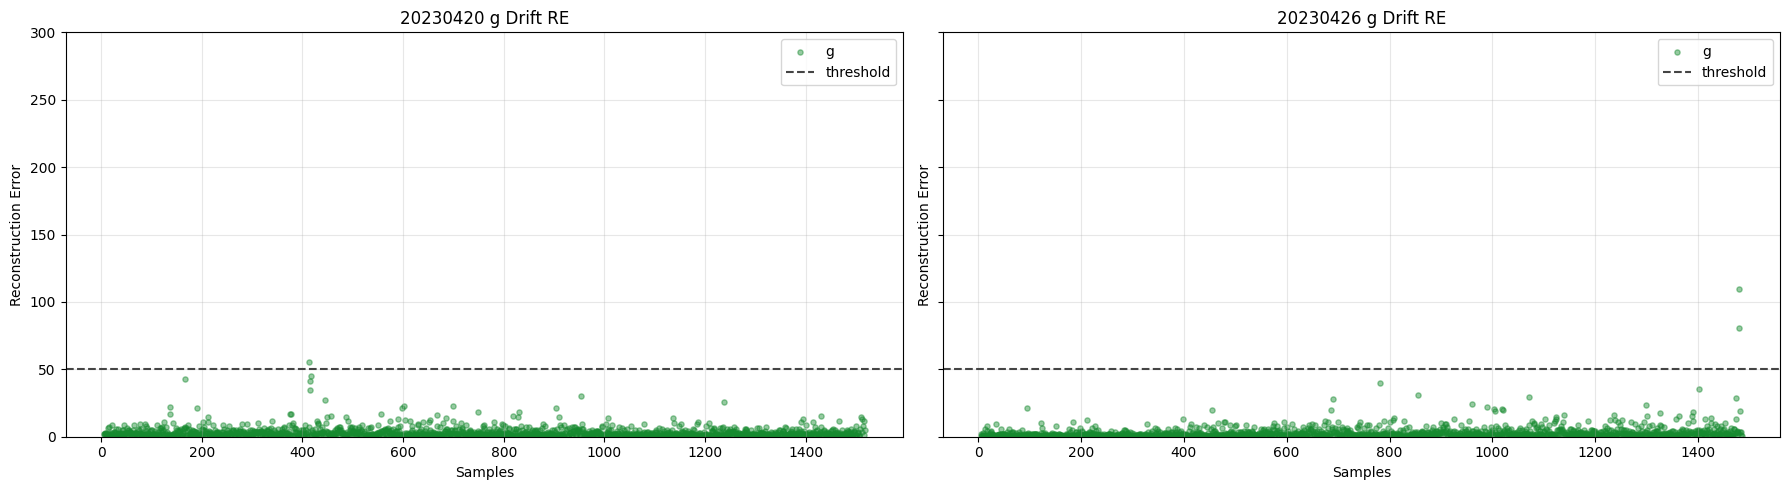

In [8]:
# g 샘플의 drift 보정 RE만 표시함
fig, axes = plt.subplots(1, len(drift_result_tables), figsize=(9 * len(drift_result_tables), 5), sharey=True)

if len(drift_result_tables) == 1:
    axes = [axes]

for ax, (name, result_df) in zip(axes, drift_result_tables.items()):
    g_df = result_df[result_df["Results"] == "g"]

    ax.scatter(
        g_df["sample_index"],
        g_df["drift_re"],
        color="#168a2f",
        alpha=0.45,
        s=14,
        label="g",
    )

    ax.axhline(RE_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5, label="threshold")
    ax.set_title(f"{name} g Drift RE")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Reconstruction Error")
    ax.set_ylim(0, 300)
    ax.set_yticks(range(0, 301, 50))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()